In [4]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


In [1]:
import matplotlib.pyplot as plt

In [6]:
from data_processor import LSTMDataPreparator, DataPreprocessor
from data_processor.builder import TargetScalerSeq2Seq
from train import DemandModelTrainer


In [7]:
data_dir = Path("..") / "data"
file_elec_consum = data_dir / 'Electricity consumption.csv'
file_weather = data_dir / 'Weather data.csv'

In [8]:
df_valid = DataPreprocessor(file_elec_consum, file_weather).feature_engineering_demand()

Loading and preparing data...
Filling values below 205 kW with historical means...
Handling weekend outliers...
Handling weekday outliers...
Threshold applied for day 0: 770.00 kW
Threshold applied for day 1: 760.00 kW
Threshold applied for day 2: 720.00 kW
Threshold applied for day 3: 700.00 kW
Threshold applied for day 4: 670.00 kW
Calculating daily energy consumption...
Processing complete!
Loading and preparing data...
Filling values below 4 with historical ...
Processing complete!


In [9]:
feature_list = [
    'energy_kW_rolling_4', 'temp_rolling_12', 'humid_rolling_12', 'Temp_Squared', 'lag_1', 'lag_2', 
    'lag_96', 'is_summer', 'is_weekend', 'is_friday', 'is_monday', 'is_winter', 'is_occuped', 
    'hour_cos', 'month_cos', 'HDD_occupied', 'CDD', "Electricity consumption (kW)","Temperature (F)", "Humidity (%)"
]

In [11]:
if __name__ == "__main__":
    
    lstm_preparator = LSTMDataPreparator(
        feature_list= feature_list,
        window=288,          
        horizon=192,       
        train_ratio=0.7,
        val_ratio=0.15,
        feature_scaler_type='minmax',
        target_scaler_type='minmax',
        verbose=True,
        target_column= "Electricity consumption (kW)"
    )
    lstm_preparator.target_scaler = TargetScalerSeq2Seq(horizon=192)
    
    lstm_preparator.prepare(df_valid)
    
    X_train, y_train = lstm_preparator.get_training_data()
    X_val, y_val = lstm_preparator.get_validation_data()
    X_test, y_test = lstm_preparator.get_test_data()
    
    all_data = lstm_preparator.get_all_data()
    
    
    print("\nData ready for LSTM model!")

1. Selecting features...
2. Creating LSTM sequences...
3. Splitting data...
4. Scaling features...
5. Scaling targets...

Data ready for LSTM model!


In [ ]:
#lstm_preparator.save_preparator_artifacts()

c:\Users\etulyon1\forecasting_electricity\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 288, 128)       │        57,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 288, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 192, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 192, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 192, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,873 (468.25 KB)

 Trainable params: 119,873 (468.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
872/872 ━━━━━━━━━━━━━━━━━━━━ 538s 604ms/step - loss: 0.1614 - mae: 0.1614 - mse: 0.0491 - val_loss: 0.0927 - val_mae: 0.0927 - val_mse: 0.0161
Epoch 2/100
872/872 ━━━━━━━━━━━━━━━━━━━━ 454s 520ms/step - loss: 0.0793 - mae: 0.0793 - mse: 0.0146 - val_loss: 0.0510 - val_mae: 0.0510 - val_mse: 0.0054
Epoch 3/100
872/872 ━━━━━━━━━━━━━━━━━━━━ 463s 531ms/step - loss: 0.0629 - mae: 0.0629 - mse: 0.0099 - val_loss: 0.0540 - val_mae: 0.0540 - val_mse: 0.0059
Epoch 4/100
872/872 ━━━━━━━━━━━━━━━━━━━━ 721s 827ms/step - loss: 0.0576 - mae: 0.0576 - mse: 0.0085 - val_loss: 0.0489 - val_mae: 0.0489 - val_mse: 0.0051
Epoch 5/100
872/872 ━━━━━━━━━━━━━━━━━━━━ 842s 965ms/step - loss: 0.0535 - mae: 0.0535 - mse: 0.0075 - val_loss: 0.0482 - val_mae: 0.0482 - val_mse: 0.0048
Epoch 6/100
872/872 ━━━━━━━━━━━━━━━━━━━━ 793s 909ms/step - loss: 0.0495 - mae: 0.0495 - mse: 0.0066 - val_loss: 0.0565 - val_mae: 0.0565 - val_mse: 0.0064
Epoch 7/100
872/872 ━━━━━━━━━━━━━━━━━━━━ 777s 890ms/step - loss: 0.046

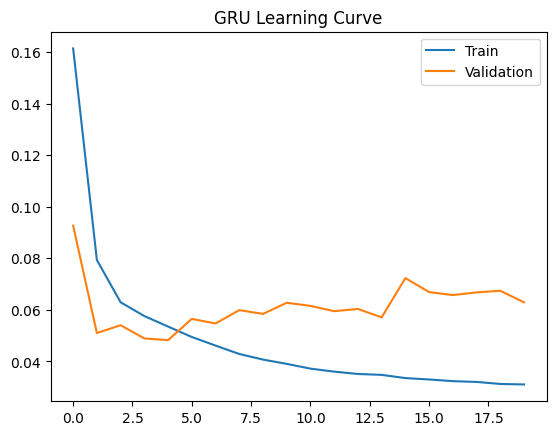

In [12]:
if __name__ == "__main__":
    
    trainer = DemandModelTrainer(
    )
    
    trainer.build_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        horizon=y_train.shape[1]
    ).compile_model().show_summary()
    
    history = trainer.train(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val
    )
    
    trainer.visualize_training()

187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 197ms/step


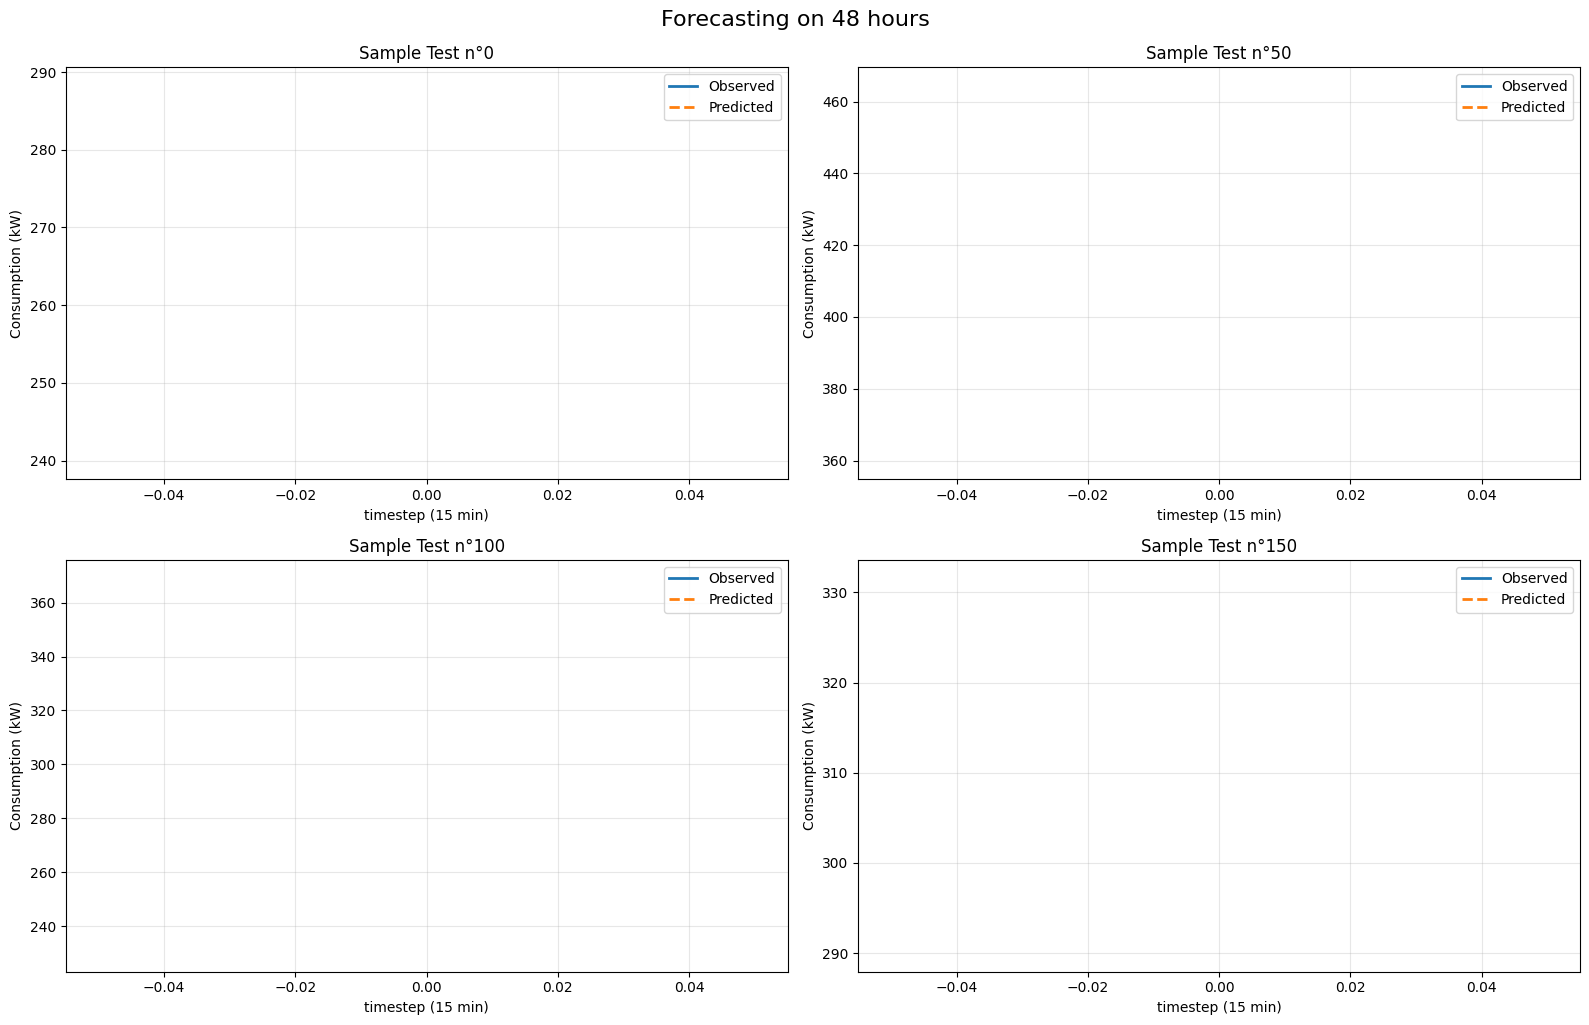

In [14]:
model_15min = trainer.get_model()
y_pred_scaled = model_15min.predict(X_test)

In [11]:
if __name__ == "__main__":
    
    
    X_lstm = lstm_preparator.X_sequences

    y_lstm = lstm_preparator.y_sequences


In [15]:
import numpy as np
from utils.predict_ci import predict_with_uncertainty

features_lstm = lstm_preparator.feature_selector.default_features

last_window_raw = df_valid[features_lstm].values[-288:]
last_window_scaled = lstm_preparator.feature_scaler.transform(last_window_raw.reshape(1, *last_window_raw.shape))
mean_scaled, std_scaled = predict_with_uncertainty(model_15min, last_window_scaled)

mean_final = lstm_preparator.target_scaler.inverse_transform(mean_scaled).flatten()
upper_bound = lstm_preparator.target_scaler.inverse_transform((mean_scaled + 1.96 * std_scaled)).flatten()
lower_bound = lstm_preparator.target_scaler.inverse_transform((mean_scaled - 1.96 * std_scaled)).flatten()
last_date = df_valid.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), periods=192, freq='15min')

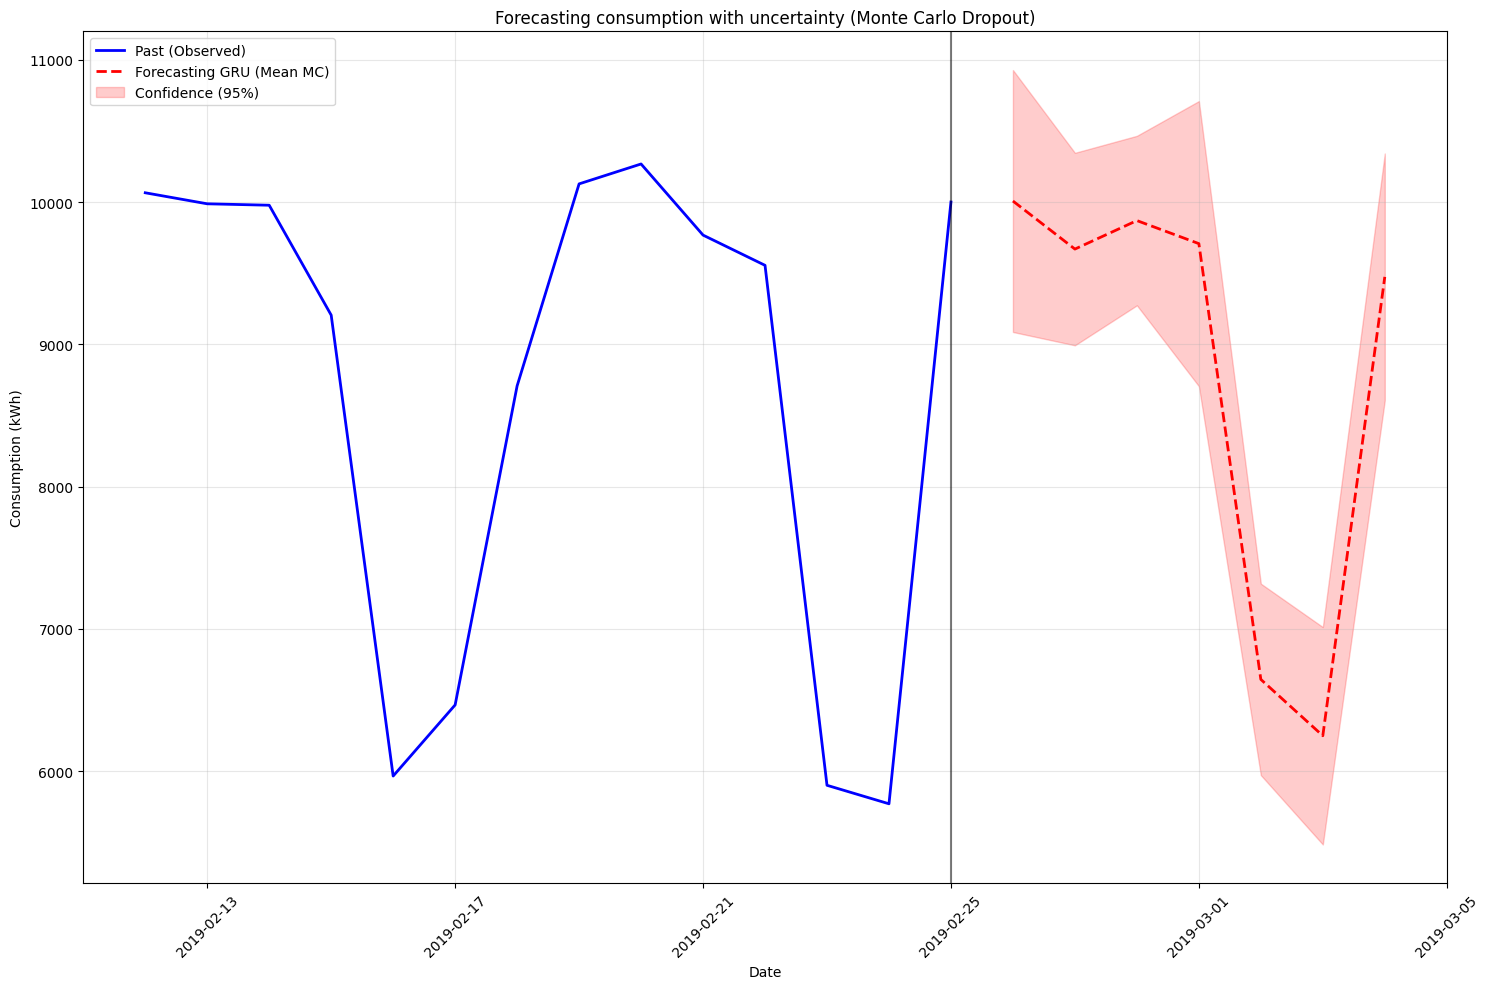

In [16]:
import matplotlib.pyplot as plt

# 1. Préparation des dates pour l'axe X (7 jours après la dernière date réelle)
last_date = df_valid.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), periods=192, freq='15min')


plt.figure(figsize=(15, 6))

past_visible = df_valid.tail(288)
plt.plot(past_visible.index, past_visible['Electricity consumption (kW)'],
         label='Passé (Données réelles)', color='blue', lw=2)

plt.plot(forecast_dates, mean_final,
         label='Forecast S2S (Mean MC)', color='red', linestyle='--', lw=2)

plt.fill_between(forecast_dates, lower_bound, upper_bound,
                 color='red', alpha=0.2, label='Confidence band (95%)')

plt.axvline(x=last_date, color='black', linestyle='-', alpha=0.5) 
plt.title(f"Forecast consumption with Incertitude (Monte Carlo Dropout)")
plt.xlabel("Date")
plt.ylabel("consumption (kW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
y_pred_scaled = model_15min.predict(X_test)
y_pred_train_scaled = model_15min.predict(X_train)

y_pred_kw = lstm_preparator.target_scaler.inverse_transform(y_pred_scaled)
y_pred_kw_train = lstm_preparator.target_scaler.inverse_transform(y_pred_train_scaled)
y_train_kw = lstm_preparator.target_scaler.inverse_transform(y_train)
y_test_kw = lstm_preparator.target_scaler.inverse_transform(y_test)

Modèle: GRU

Performance sur Train:
MSE: 697984.827580
RMSE: 835.454863
MAE: 607.701779
R²: 0.862512

Performance sur Test:
MSE: 959201.626483
RMSE: 979.388394
MAE: 705.820234
R²: 0.676041


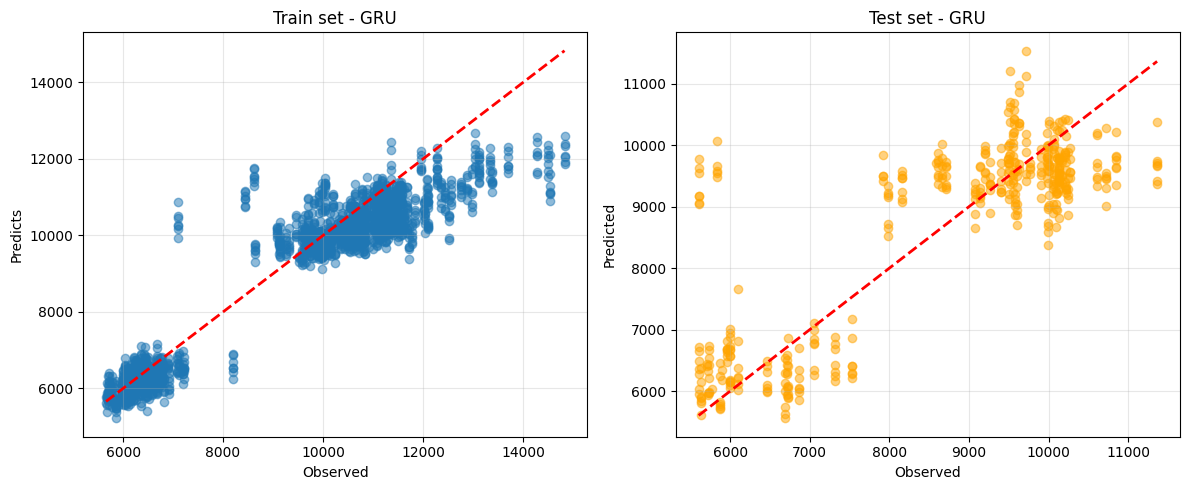

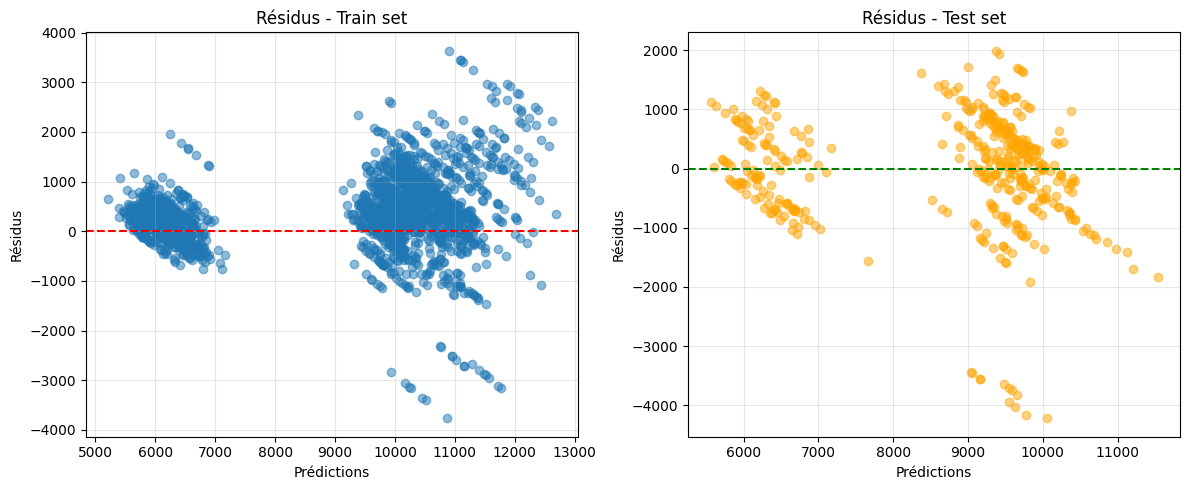

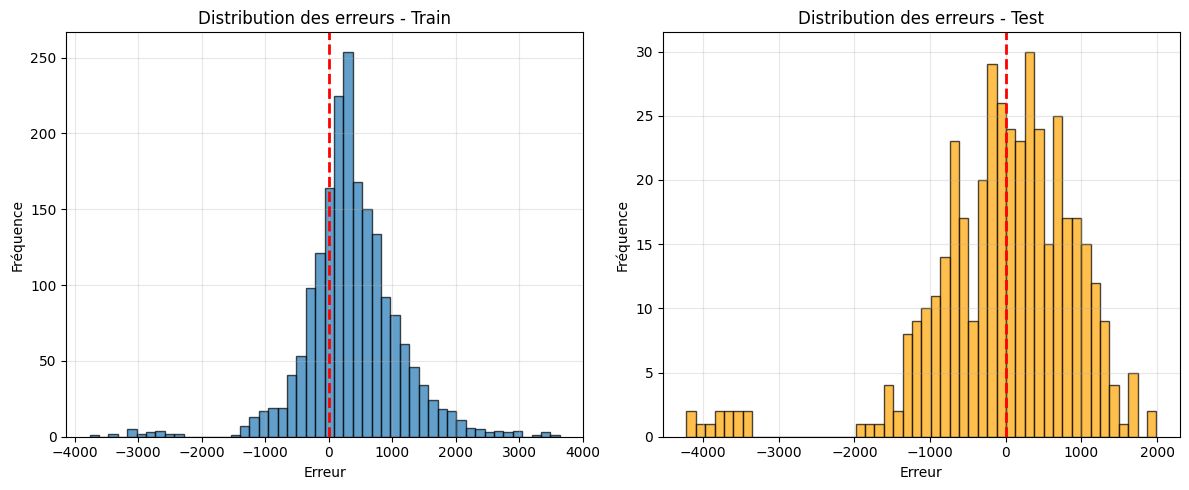

In [18]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{'='*50}")
    print(f"Performance sur {dataset_name}:")
    print(f"{'='*50}")
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R²: {r2:.6f}")

    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
print(f"Modèle: GRU")
# Assurez-vous d'utiliser les versions dé-normalisées pour les métriques
train_metrics = evaluate_model(y_train_kw, y_pred_kw_train, "Train")
test_metrics = evaluate_model(y_test_kw, y_pred_kw, "Test")

# 6. Visualisation des prédictions vs vraies valeurs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
axes[0].scatter(y_train_kw, y_pred_kw_train, alpha=0.5)
axes[0].plot([y_train_kw.min(), y_train_kw.max()], [y_train_kw.min(), y_train_kw.max()], 'r--', lw=2)
axes[0].set_xlabel('Observed')
axes[0].set_ylabel('Predicts')
axes[0].set_title('Train set - S2S')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test_kw, y_pred_kw, alpha=0.5, color='orange')
axes[1].plot([y_test_kw.min(), y_test_kw.max()], [y_test_kw.min(), y_test_kw.max()], 'r--', lw=2)
axes[1].set_xlabel('Observed')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test set - S2S')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

residuals_train = y_train_kw - y_pred_kw_train
residuals_test = y_test_kw - y_pred_kw

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred_kw_train, residuals_train, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Forecasts')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Résidus - Train set')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_kw, residuals_test, alpha=0.5, color='orange')
axes[1].axhline(y=0, color='g', linestyle='--')
axes[1].set_xlabel('Forecasts')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Résidus - Test set')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals_train.flatten(), bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution of errors - Train')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_test.flatten(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Erreo')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution of errors - Test')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
if __name__ == "__main__":
    
    lstm_preparator = LSTMDataPreparator(
        feature_list= feature_list,
        window=288,          
        horizon=192,       
        train_ratio=1.0,
        val_ratio=0.00,
        feature_scaler_type='minmax',
        target_scaler_type='minmax',
        verbose=True
    )
    lstm_preparator.target_scaler = TargetScalerSeq2Seq()
    
    lstm_preparator.prepare(df_valid)
    
    X_train, y_train = lstm_preparator.get_training_data()
    
    all_data = lstm_preparator.get_all_data()
    
    
    print("\nData ready for LSTM model!")

In [ ]:
if __name__ == "__main__":
    
    trainer = DemandModelTrainer(
    )
    
    trainer.build_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        horizon=y_train.shape[1]
    ).compile_model().show_summary()
    
    history = trainer.train(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val
    )
    
    trainer.visualize_training()

In [ ]:
import numpy as np
from utils.predict_ci import predict_with_uncertainty
model_15min = trainer.get_model()


features_lstm = lstm_preparator.feature_selector.default_features

last_window_raw = df_valid[features_lstm].values[-288:]
last_window_scaled = lstm_preparator.feature_scaler.transform(last_window_raw.reshape(1, *last_window_raw.shape))
mean_scaled, std_scaled = predict_with_uncertainty(model_15min, last_window_scaled)

mean_final = lstm_preparator.target_scaler.inverse_transform(mean_scaled).flatten()
upper_bound = lstm_preparator.target_scaler.inverse_transform((mean_scaled + 1.96 * std_scaled)).flatten()
lower_bound = lstm_preparator.target_scaler.inverse_transform((mean_scaled - 1.96 * std_scaled)).flatten()
last_date = df_valid.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), periods=192, freq='15min')

In [ ]:
import numpy as np
from utils.predict_ci import predict_with_uncertainty

features_lstm = lstm_preparator.feature_selector.default_features

last_window_raw = df_valid[features_lstm].values[-288:]
last_window_scaled = lstm_preparator.feature_scaler.transform(last_window_raw.reshape(1, *last_window_raw.shape))
mean_scaled, std_scaled = predict_with_uncertainty(model_15min, last_window_scaled)

mean_final = lstm_preparator.target_scaler.inverse_transform(mean_scaled).flatten()
upper_bound = lstm_preparator.target_scaler.inverse_transform((mean_scaled + 1.96 * std_scaled)).flatten()
lower_bound = lstm_preparator.target_scaler.inverse_transform((mean_scaled - 1.96 * std_scaled)).flatten()
last_date = df_valid.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), periods=192, freq='15min')

In [ ]:
import matplotlib.pyplot as plt

# 1. Préparation des dates pour l'axe X (7 jours après la dernière date réelle)
last_date = df_valid.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), periods=192, freq='15min')


plt.figure(figsize=(15, 6))

past_visible = df_valid.tail(288)
plt.plot(past_visible.index, past_visible['Electricity consumption (kW)'],
         label='Passé (Données réelles)', color='blue', lw=2)

plt.plot(forecast_dates, mean_final,
         label='Forecast S2S (Mean MC)', color='red', linestyle='--', lw=2)

plt.fill_between(forecast_dates, lower_bound, upper_bound,
                 color='red', alpha=0.2, label='Confidence band (95%)')

plt.axvline(x=last_date, color='black', linestyle='-', alpha=0.5) 
plt.title(f"Forecast consumption with Incertitude (Monte Carlo Dropout)")
plt.xlabel("Date")
plt.ylabel("consumption (kW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()